# **Fuzzy Logic — Smart Bin Motor Stepper Speed Control**

Dalam pengerjaan soal no 2 UTS ini, saya menggunakan pendekatan logika fuzzy untuk menerjemahkan input fisik menjadi keputusan mekanik yang presisi. Berikut adalah tahapan yang saya lakukan:

1. Inisialisasi Semesta Pembicaraan: Saya menetapkan rentang kerja untuk setiap variabel. Untuk input (berat), saya tentukan batas 0 hingga 1000 gram, sedangkan untuk output (kecepatan), saya gunakan skala PWM 0 hingga 255 sesuai standar mikrokontroler.

2. Perancangan Fungsi Keanggotaan: Saya menerapkan fungsi segitiga (Triangular Membership Function) untuk kategori Ringan, Sedang, dan Berat. Saya sengaja memberikan area overlap (tumpang tindih) antar himpunan agar transisi kecepatan motor nantinya berlangsung halus (biar tidk kaku/patah).

3. Penyusunan Aturan (Rule Base): Saya merumuskan tiga aturan utama yang menghubungkan beban dengan kecepatan. Prinsip yang saya pegang adalah perlindungan mekanis, maksudnya adalah semakin berat beban yang dideteksi load cell, maka perintah kecepatan yang saya berikan ke motor akan semakin melambat demi menjaga momentum.

4. Inferensi & Defuzzifikasi: Menggunakan metode Mamdani, saya memproses input berat yang masuk menjadi area solusi fuzzy. Untuk mendapatkan nilai PWM konkret, saya menerapkan metode Centroid, sehingga sistem menghasilkan satu angka kecepatan yang paling optimal.

5. Evaluasi & Visualisasi: Terakhir, saya membuat simulasi untuk berbagai skenario berat sampah. Saya juga menyertakan visualisasi grafik agar tim dapat melihat bagaimana sistem "berpikir" dalam menentukan kecepatan berdasarkan derajat keanggotaan inputnya.

# **CELL 1 — Install & Import Library**

Install scikit-fuzzy terlebih dahulu (jalankan sekali di Colab)
`!pip install scikit-fuzzy`

In [70]:
import numpy as np # Library utk operasi array numerik
import skfuzzy as fuzz # Library utama logika fuzzy (trimf, dll)
import skfuzzy.control as ctrl # Modul sistem kontrol fuzzy (Rule, ControlSystem, dll)
import matplotlib.pyplot as plt # Library untuk visualisasi/grafik
import matplotlib # Library matplotlib utama (untuk konfigurasi)

matplotlib.rcParams['figure.dpi'] = 120 # Set resolusi gambar agar lebih tajam (opsional aje ini biar kerenn)
matplotlib.rcParams['font.family'] = 'DejaVu Sans' # Set font default grafik

print(f"   numpy version     : {np.__version__}")
print(f"   scikit-fuzzy      : {fuzz.__version__ if hasattr(fuzz, '__version__') else 'installed'}")
print(f"   matplotlib version: {matplotlib.__version__}")

   numpy version     : 2.0.2
   scikit-fuzzy      : 0.5.0
   matplotlib version: 3.10.0


# **CELL 2 — Definisi Universe (Semesta Pembicaraan)**

Universe = rentang nilai yang mungkin untuk setiap variabel

`np.arange(start, stop, step) > array dari 'start' sampai 'stop' dengan jarak 'step'`

In [71]:
berat_universe = np.arange(0, 1002, 1) # Universe variabel INPUT: berat sampah 0–1001 gram, step 1 gram
kecepatan_universe = np.arange(0, 256, 1) # Universe variabel OUTPUT: nilai PWM kecepatan motor 0–255, step 1

print(f"   Berat     : {berat_universe[0]} – {berat_universe[-1]} gram  ({len(berat_universe)} titik)")
print(f"   Kecepatan : {kecepatan_universe[0]} – {kecepatan_universe[-1]} PWM  ({len(kecepatan_universe)} titik)")

   Berat     : 0 – 1001 gram  (1002 titik)
   Kecepatan : 0 – 255 PWM  (256 titik)


# **CELL 3 — Antecedent: Variabel Input (Sensor Berat)**

ctrl.Antecedent = mendefinisikan variabel INPUT dalam sistem fuzzy

Parameter: (universe_array, 'nama_variabel')

In [72]:
berat = ctrl.Antecedent(berat_universe, 'berat_sampah') # Buat variabel antecedent bernama 'berat_sampah'

print(f"   Nama variabel : '{berat.label}'")
print(f"   Domain        : {berat.universe[0]} – {berat.universe[-1]}")

   Nama variabel : 'berat_sampah'
   Domain        : 0 – 1001


# **CELL 4 — Consequent: Variabel Output (Kecepatan Motor)**

ctrl.Consequent = mendefinisikan variabel OUTPUT dalam sistem fuzzy

Parameter: (universe_array, 'nama_variabel')

In [73]:
kecepatan = ctrl.Consequent(kecepatan_universe, 'kecepatan_motor') # Bikin variabel consequent bernama 'kecepatan_motor'

# Netepin dl metode defuzzifikasi pake centeroid, metod ini ngitung titik pusat massa dari area hasil agregasi
kecepatan.defuzzify_method = 'centroid'

print(f"   Nama variabel       : '{kecepatan.label}'")
print(f"   Domain              : {kecepatan.universe[0]} – {kecepatan.universe[-1]}")
print(f"   Metode defuzzifikasi: {kecepatan.defuzzify_method}")

   Nama variabel       : 'kecepatan_motor'
   Domain              : 0 – 255
   Metode defuzzifikasi: centroid


# **CELL 5 — Fungsi Keanggotaan trimf untuk INPUT (Sensor Berat)**

fuzz.trimf(universe, [a, b, c]) → Triangular Membership Function

[a, b, c]: a = kaki kiri (μ=0), b = puncak (μ=1), c = kaki kanan (μ=0)

In [74]:
# Himpunan Ringan : Puncaknya di 0 gram, turun ke 0 di 400 gram
# [0, 0, 400] -> kaki kiri = 0, puncak = 0, kaki kanan = 400, nah ini arrtinya sangat ringan di dkt 0 gram, tdk ringan di 400 gram
berat['ringan'] = fuzz.trimf(berat.universe, [0, 0, 400])

# Himpunan Sedang : Naik dari 300, puncaknya di 500 gram, turun ke 700 gram
# [300, 500, 700] -> nah simetris, puncak tepat di tengah rentang 300–700
berat['sedang'] = fuzz.trimf(berat.universe, [300, 500, 700])

# Himpunan Berat : Naik dari 600 gram, ke pucuk 1001 gram
# [600, 1001, 1001] -> kaki kiri = 600, puncak = 1001, kaki kanan = 1001, nah mulai berat di 600 gram dan sangat berat di 1001 gram keatas
berat['berat'] = fuzz.trimf(berat.universe, [600, 1001, 1001])

print("Fungsi keanggotaan INPUT (berat sampah) berhasil dibuat")
print("   Himpunan yang terdefinisi:", list(berat.terms.keys()))


Fungsi keanggotaan INPUT (berat sampah) berhasil dibuat
   Himpunan yang terdefinisi: ['ringan', 'sedang', 'berat']


# **CELL 6 — Fungsi Keanggotaan trimf untuk OUTPUT (Kecepatan Motor)**



In [75]:
# Himpunan Lambat : Puncaknya di 0 PM, turun ke 0 di 100 PM
# [0, 0, 100] -> kaki kiri = 0, puncak = 0, kaki kanan = 100, artinya motor sangat lambat di nilai PWM rendah, tp tidak lambat lagi ketika 100
kecepatan['lambat'] = fuzz.trimf(kecepatan.universe, [0, 0, 100])

# Himpunan Normal : Naik dari 80, pdan puncaknya di 130 PWM, turun ke 180 PWM
# [80, 130, 180] → simetris, puncak di tengah rentang 80–180
kecepatan['normal'] = fuzz.trimf(kecepatan.universe, [80, 130, 180])

# Himpunan Cepat : Naik dari 160 PWM dan puncaknya di 225 PWM
# [160, 255, 255] -> kaki kiri = 160, puncak = 255, kaki kanan = , asrtinya mulai cepat ketika 160 PWM dan sangat cepat di 255 (maksimumnya)
kecepatan['cepat'] = fuzz.trimf(kecepatan.universe, [160, 255, 255])

print("   Himpunan yang terdefinisi:", list(kecepatan.terms.keys()))



   Himpunan yang terdefinisi: ['lambat', 'normal', 'cepat']


# **CELL 7 — Rule Base (Aturan Fuzzy)**

ctrl.Rule(antecedent, consequent) -> mendefinisikan satu aturan IF-THEN

Pola: IF [kondisi input] THEN [aksi output]

In [76]:
# Aturan 1, jika berat sampahnya = ringan, maka kecepatan motor = cepat
rule1 = ctrl.Rule(berat['ringan'], kecepatan['cepat'])

# Aturan 2, jika berat sampahnya = sedang, maka kecepatan motor = normal
rule2 = ctrl.Rule(berat['sedang'], kecepatan['normal'])

#Aturan 3, jika berat sampahnya = berat, maka kecepatan motor = lambat
rule3 = ctrl.Rule(berat['berat'], kecepatan['lambat'])

# **CELL 8 — Control System & Simulasi**

- `ctrl.ControlSystem([list of rules])` -> merakit semua aturan menjadi satu sistem

- `ctrl.ControlSystemSimulation(control_system)` -> membuat objek simulasi

In [77]:
# Masukan ketiga aturan kedalam satu sistem kontrol fuzzy
smartbin_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])

# Objek simulasi ini yang nantinya bakal dipake untk menghitung output berdasarkan nilai input yg diberikan
smartbin_sim = ctrl.ControlSystemSimulation(smartbin_ctrl)

print("   Jumlah aturan aktif:", len(list(smartbin_ctrl.rules)))

# Simulasi dengan 1 nilai input
test_berat = 250

smartbin_sim.input['berat_sampah'] = test_berat

# Run kannn proses inferensi fuzzy nya:
#   1. Fuzzifikasi: ngitung derajat keanggotaan input ke tiap himpunan
#   2. Evaluasi aturan: terapkan semua rule yang aktif
#   3. Agregasi: gabungkan output semua aturan
#   4. Defuzzifikasi: konversi ke nilai crisp (centroid)
smartbin_sim.compute()

hasil_kecepatan = smartbin_sim.output['kecepatan_motor']

print(f"   Input  -> Berat Sampah    : {test_berat} gram")
print(f"   Output -> Kecepatan Motor : {hasil_kecepatan:.2f} PWM")

   Jumlah aturan aktif: 3
   Input  -> Berat Sampah    : 250 gram
   Output -> Kecepatan Motor : 215.72 PWM


# **CELL 9 — Visualisasi Grafik Fungsi Keanggotaan**

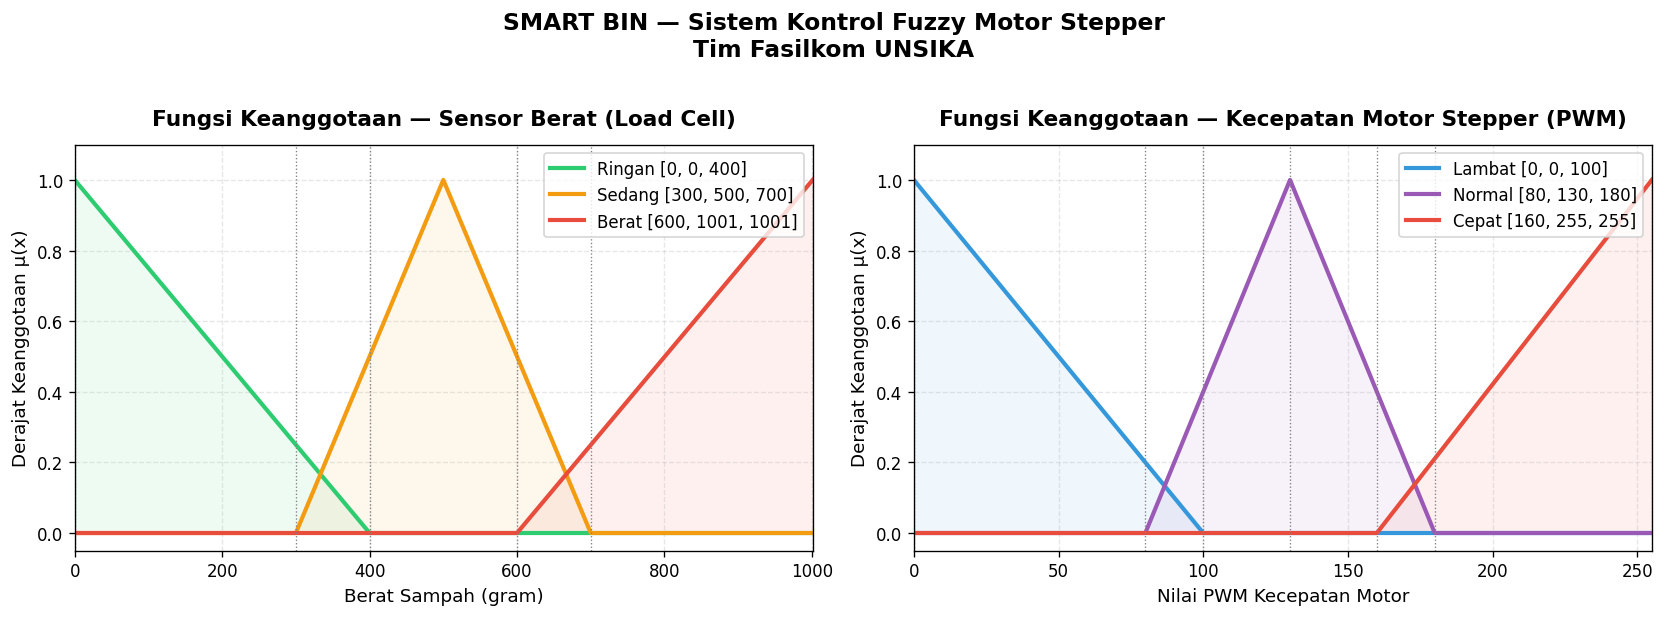

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot Kiri: Input, Berat Sampah
ax1 = axes[0]

ax1.plot(
    berat.universe,
    fuzz.trimf(berat.universe, [0, 0, 400]),
    color='#2ecc71',
    linewidth=2.5,
    label='Ringan [0, 0, 400]'
)

ax1.plot(
    berat.universe,
    fuzz.trimf(berat.universe, [300, 500, 700]),
    color='#f39c12',
    linewidth=2.5,
    label='Sedang [300, 500, 700]'
)

ax1.plot(
    berat.universe,
    fuzz.trimf(berat.universe, [600, 1001, 1001]),
    color='#e74c3c',
    linewidth=2.5,
    label='Berat [600, 1001, 1001]'
)

ax1.set_title('Fungsi Keanggotaan — Sensor Berat (Load Cell)',
              fontsize=13, fontweight='bold', pad=12)

ax1.set_xlabel('Berat Sampah (gram)', fontsize=11) # Label sumbu X
ax1.set_ylabel('Derajat Keanggotaan μ(x)', fontsize=11) # Label sumbu Y

ax1.set_xlim(0, 1001)
ax1.set_ylim(-0.05, 1.1)

ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Tambahkan garis vertikal untuk menandai batas antar himpunan
for x_val, label_txt in [(0, '0'), (300, '300'), (400, '400'),
                          (600, '600'), (700, '700'), (1001, '1001')]:
    ax1.axvline(x=x_val, color='gray', linewidth=0.8, linestyle=':')


ax1.fill_between(berat.universe,
                 fuzz.trimf(berat.universe, [0, 0, 400]),
                 alpha=0.08, color='#2ecc71')

ax1.fill_between(berat.universe,
                 fuzz.trimf(berat.universe, [300, 500, 700]),
                 alpha=0.08, color='#f39c12')

ax1.fill_between(berat.universe,
                 fuzz.trimf(berat.universe, [600, 1001, 1001]),
                 alpha=0.08, color='#e74c3c')


# Subplot Kanan: Output,  Kecepatan Motor
ax2 = axes[1] # Ambil sumbu kedua (kanan)

ax2.plot(
    kecepatan.universe,
    fuzz.trimf(kecepatan.universe, [0, 0, 100]),
    color='#3498db',
    linewidth=2.5,
    label='Lambat [0, 0, 100]'
)

ax2.plot(
    kecepatan.universe,
    fuzz.trimf(kecepatan.universe, [80, 130, 180]),
    color='#9b59b6',
    linewidth=2.5,
    label='Normal [80, 130, 180]'
)

ax2.plot(
    kecepatan.universe,
    fuzz.trimf(kecepatan.universe, [160, 255, 255]),
    color='#e74c3c',
    linewidth=2.5,
    label='Cepat [160, 255, 255]'
)

ax2.set_title('Fungsi Keanggotaan — Kecepatan Motor Stepper (PWM)',
              fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Nilai PWM Kecepatan Motor', fontsize=11)
ax2.set_ylabel('Derajat Keanggotaan μ(x)', fontsize=11)

ax2.set_xlim(0, 255)
ax2.set_ylim(-0.05, 1.1)

ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

# Tambahkan garis vertikal
for x_val in [0, 80, 100, 130, 160, 180, 255]:
    ax2.axvline(x=x_val, color='gray', linewidth=0.8, linestyle=':')

ax2.fill_between(kecepatan.universe,
                 fuzz.trimf(kecepatan.universe, [0, 0, 100]),
                 alpha=0.08, color='#3498db')

ax2.fill_between(kecepatan.universe,
                 fuzz.trimf(kecepatan.universe, [80, 130, 180]),
                 alpha=0.08, color='#9b59b6')

ax2.fill_between(kecepatan.universe,
                 fuzz.trimf(kecepatan.universe, [160, 255, 255]),
                 alpha=0.08, color='#e74c3c')

plt.suptitle('SMART BIN — Sistem Kontrol Fuzzy Motor Stepper\nTim Fasilkom UNSIKA',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# **CELL 10 — Uji Simulasi dengan Berbagai Nilai Input**

In [80]:
print("=" * 60)
print("TABEL SIMULASI FUZZY — SMART BIN MOTOR STEPPER") #HEADER PEMANIS aj
print("=" * 60)
print(f"   {'Berat Input (gram)':>20} {'Kecepatan PWM':>15} {'Kategori':>12}")
print(f"   {'-'*52}")

# Daftar nilai berat yang akan diuji
test_cases = [
    (50,   "Ringan sekali"),
    (150,  "Ringan"),
    (300,  "Ringan-Sedang"),
    (400,  "Batas Ringan"),
    (500,  "Sedang"),
    (600,  "Sedang-Berat"),
    (700,  "Batas Sedang"),
    (800,  "Berat"),
    (950,  "Berat sekali"),
    (1001, "Berat Maksimum"),
]

for berat_val, keterangan in test_cases:

    # Input nilai berat ke simulasi
    smartbin_sim.input['berat_sampah'] = berat_val

    # Run inferensi fuzzy
    smartbin_sim.compute()

    # Ambil nilai PWM hasil defuzzifikasi
    pwm_out = smartbin_sim.output['kecepatan_motor']

    # Tentukan kategoriny berdasarkan nilai PWM
    if pwm_out <= 100:
        kategori = "Lambat"
    elif pwm_out <= 180:
        kategori = "Normal"
    else:
        kategori = "Cepat"

    print(f"   {berat_val:>5} gram ({keterangan:<15}) -> {pwm_out:>7.2f} PWM  {kategori}")

print(f"\n{'='*60}")
print("KESIMPULAN:")
print("   • Berat < 400 gram berarti PWM tinggi (motor CEPAT)")
print("   • Berat 400–600 gram berarti PWM sedang (motor NORMAL)")
print("   • Berat > 600 gram berarti PWM rendah (motor LAMBAT)")
print("")
print("Transisi antara kategori bersifat GRADUAL (tidak tiba-tiba),")
print("inilah keunggulan Logika Fuzzy dibanding kontrol on/off biasa.")


TABEL SIMULASI FUZZY — SMART BIN MOTOR STEPPER
     Berat Input (gram)   Kecepatan PWM     Kategori
   ----------------------------------------------------
      50 gram (Ringan sekali  ) ->  222.89 PWM  Cepat
     150 gram (Ringan         ) ->  220.09 PWM  Cepat
     300 gram (Ringan-Sedang  ) ->  213.15 PWM  Cepat
     400 gram (Batas Ringan   ) ->  130.00 PWM  Normal
     500 gram (Sedang         ) ->  130.00 PWM  Normal
     600 gram (Sedang-Berat   ) ->  130.00 PWM  Normal
     700 gram (Batas Sedang   ) ->   44.06 PWM  Lambat
     800 gram (Berat          ) ->   38.91 PWM  Lambat
     950 gram (Berat sekali   ) ->   33.81 PWM  Lambat
    1001 gram (Berat Maksimum ) ->   33.33 PWM  Lambat

KESIMPULAN:
   • Berat < 400 gram berarti PWM tinggi (motor CEPAT)
   • Berat 400–600 gram berarti PWM sedang (motor NORMAL)
   • Berat > 600 gram berarti PWM rendah (motor LAMBAT)

Transisi antara kategori bersifat GRADUAL (tidak tiba-tiba),
inilah keunggulan Logika Fuzzy dibanding kontrol on/o